# 0151GBO, cold chain

RAMP calibration of this client, season by season and then month by month.

The cells read the committed results in `resultats/`. The replay cell runs the RAMP engine
again on the published input files and checks that it gives back the published profiles
exactly. To calibrate everything again from the meter data, see `src/run.py` (about fifteen
hours).

In [1]:
CLIENT = "0151GBO"

import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

REPO = Path.cwd().resolve().parents[1]      # notebooks/<type>/ -> repository root
sys.path.append(str(REPO / "src"))
import calibration as K

SEASONS = REPO / "resultats" / "reference_saison"
MONTHS = REPO / "resultats" / "calib_mois"


def results(folder):
    """Results of this client in a folder, one per target."""
    return [json.load(open(p)) for p in sorted(folder.glob(f"{CLIENT}__*.json"))]


def summary(ps):
    """One row per target: days, verdict, missed criteria, four key gaps, RAMP durations."""
    return pd.DataFrame([{"target": p["cible"], "days": p["jours_retenus"], "verdict": p["verdict"],
                          "missed criteria": ", ".join(p["manques"]) or "-",
                          "NRMSE (%)": round(100 * p["mesures"]["NRMSE"], 1),
                          "harmonics (%)": round(100 * p["mesures"]["FFT_err"], 1),
                          "energy (%)": round(p["mesures"]["err_E_pct"], 1),
                          "peak time (h)": p["mesures"]["ECART_PICS_h"],
                          "func_cycle (min)": p["func_cycle"], "period (min)": p["L_etoile"]}
                         for p in ps])


def show(folder, pattern):
    """Every figure of a folder matching the pattern, in file order."""
    for path in sorted(folder.glob(pattern)):
        display(Image(filename=str(path), width=900))


seasons, months = results(SEASONS), results(MONTHS)
print(f"{len(seasons)} seasonal targets and {len(months)} monthly targets for {CLIENT}")

7 seasonal targets and 16 monthly targets for 0151GBO


## Seasons

Verdict of the validation contract: *validee* (every criterion met), *rejetee* (at least one
criterion missed) or *non verifiable* (the days of the target are too few or too scattered to
judge a model at the 10 % level). The gaps are between the mean measured profile and the mean
profile simulated by RAMP.

In [2]:
summary(seasons)

,target,days,verdict,missed criteria,NRMSE (%),harmonics (%),energy (%),peak time (h),func_cycle (min),period (min)
0,Mai | avant 2025-09-17,28,rejetee,FFT_err,8.3,25.1,-0.0,0.75,10,30
1,Mai | depuis 2025-09-17,20,non verifiable,-,8.9,19.8,-1.3,0.00,15,15
2,Octobre | depuis 2025-09-17,30,rejetee,"FFT_err, ECART_PICS_h",8.4,23.1,0.3,3.00,60,30
3,Saison des pluies | avant 2025-09-17,60,non verifiable,FFT_err,7.1,26.8,-0.3,1.50,15,30
4,Saison des pluies | depuis 2025-09-17,63,non verifiable,"FFT_err, ECART_PICS_h",6.8,20.2,1.7,3.00,15,15
5,Saison seche | avant 2025-09-17,32,rejetee,"FFT_err, ECART_PICS_h",10.7,20.9,-0.9,3.00,5,15
6,Saison seche | depuis 2025-09-17,119,non verifiable,ECART_PICS_h,8.6,15.3,-1.3,1.25,15,30


### Retained RAMP parameters

Windows and cycle ranges, share of time running, durations, and the daily peaks against the
nameplate power entered in RAMP.

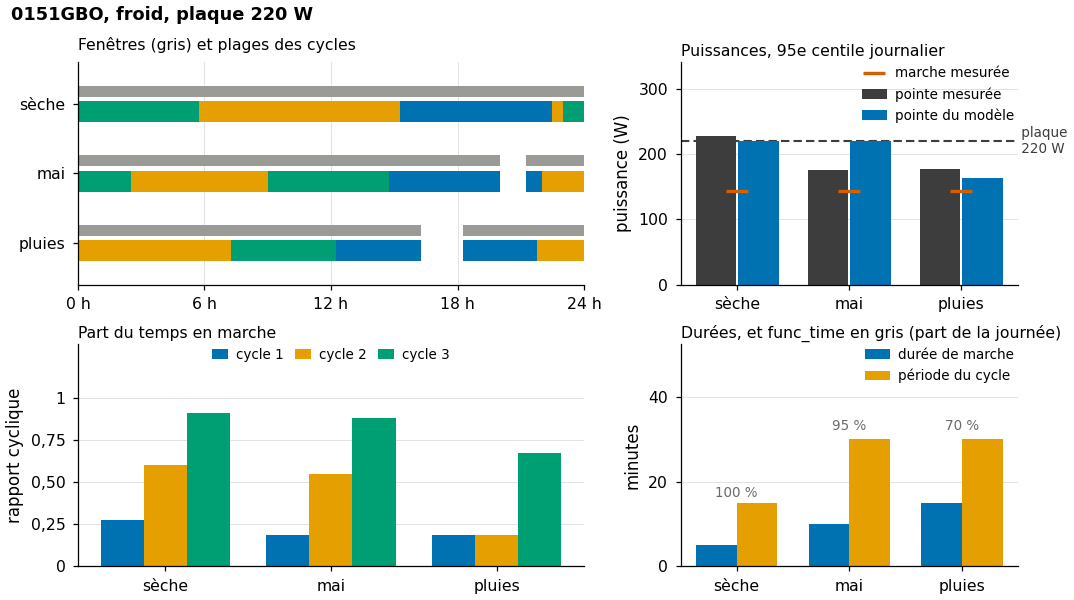

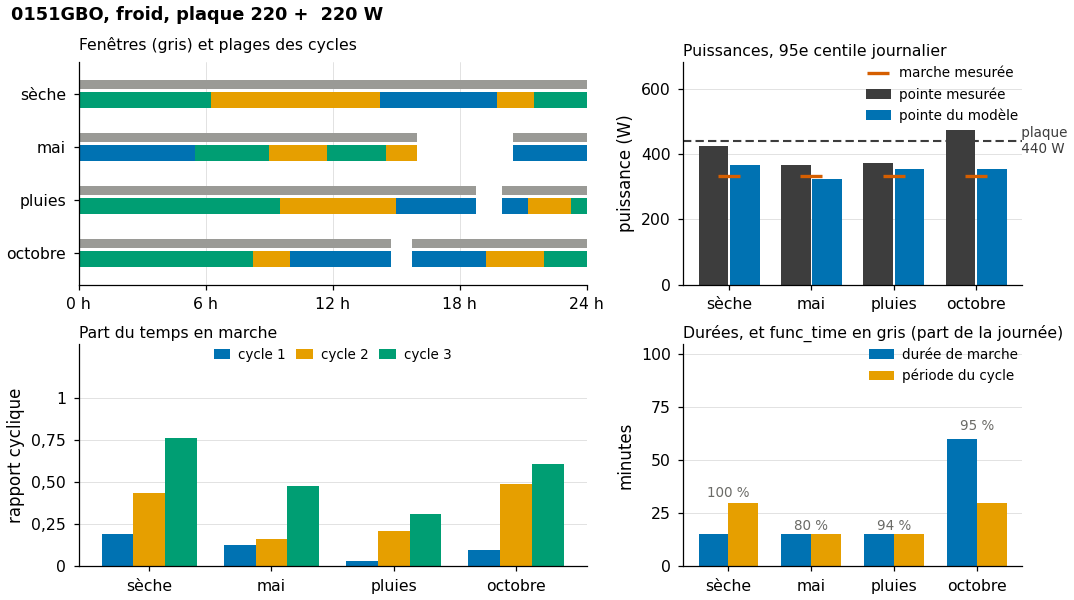

In [3]:
show(SEASONS / "publication" / "figures", f"parametres_{CLIENT}_*.png")

### Measured and simulated profiles

Grey line: mean measured profile; blue line: RAMP model; grey band: 90 % band of the noise of the
mean. Lower panel: model minus measurement, relative to that noise.

**Mai | avant 2025-09-17**

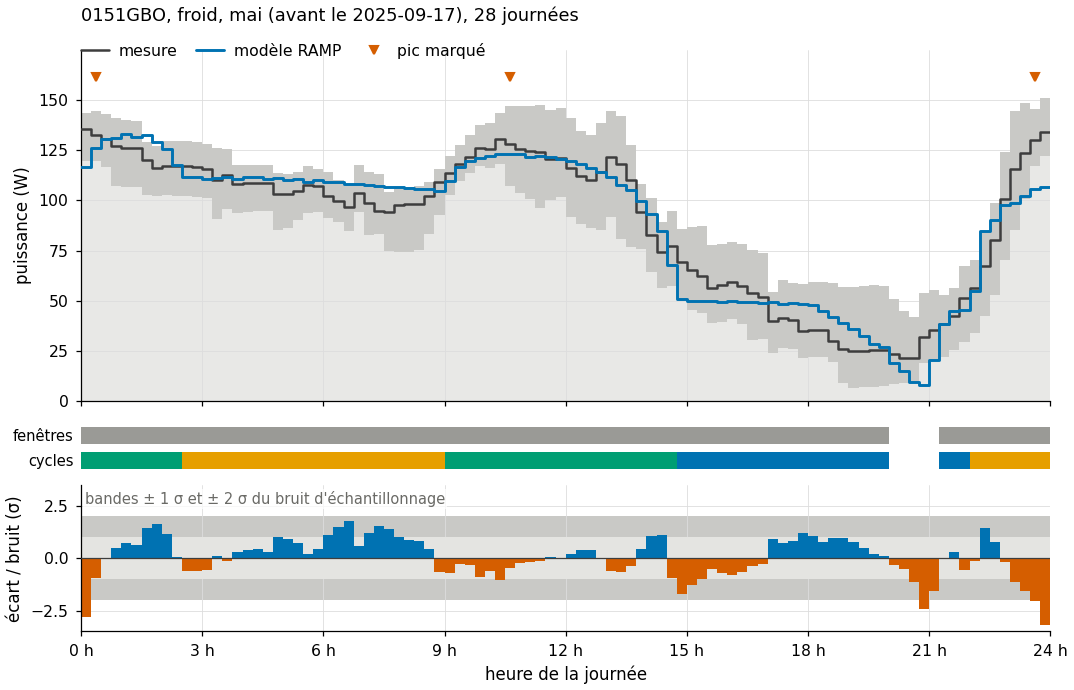

**Mai | depuis 2025-09-17**

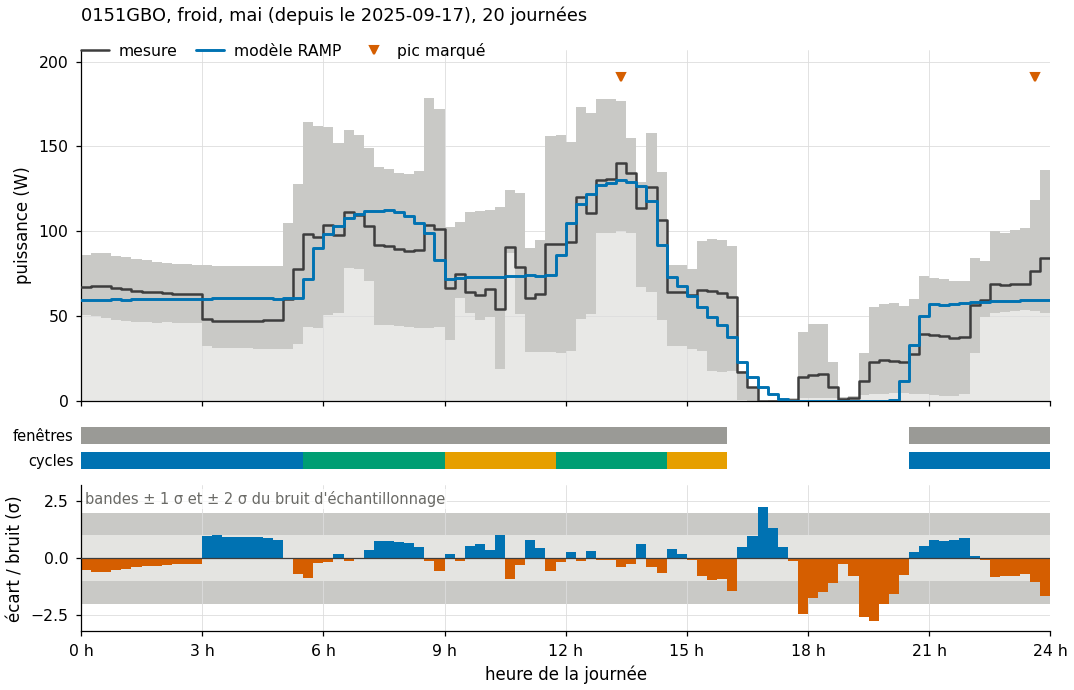

**Octobre | depuis 2025-09-17**

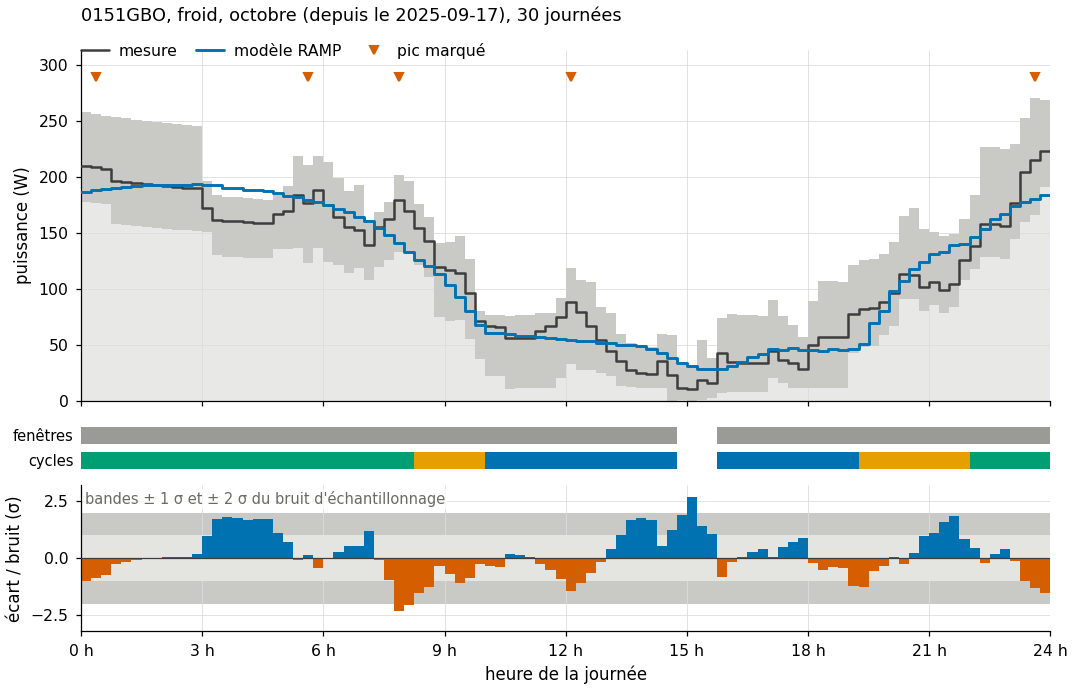

**Saison des pluies | avant 2025-09-17**

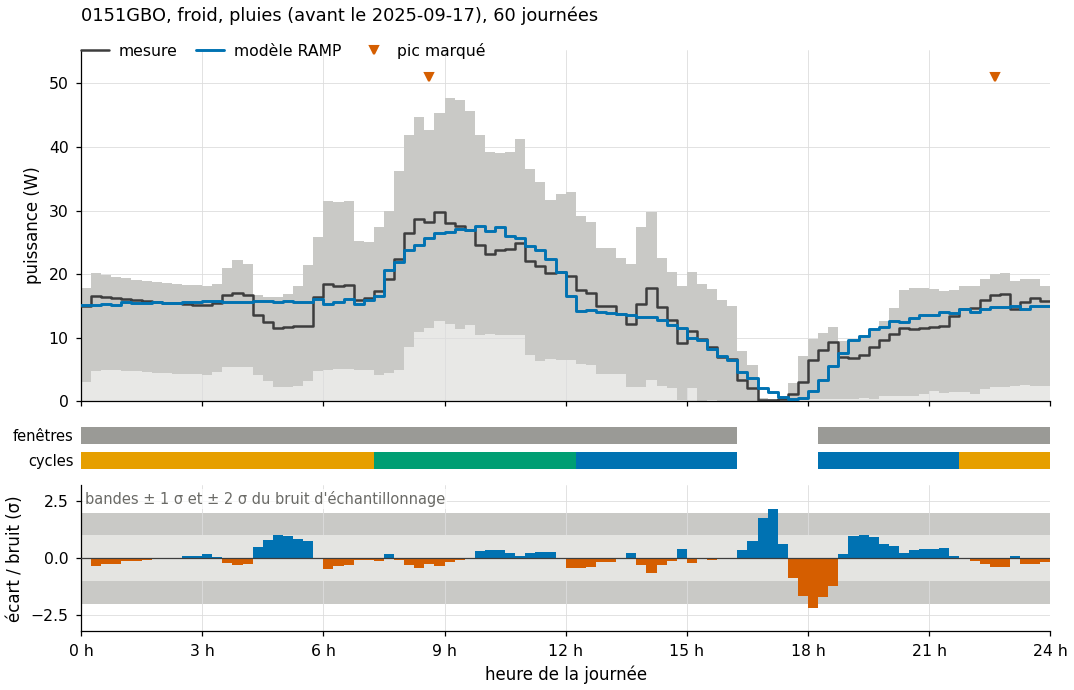

**Saison des pluies | depuis 2025-09-17**

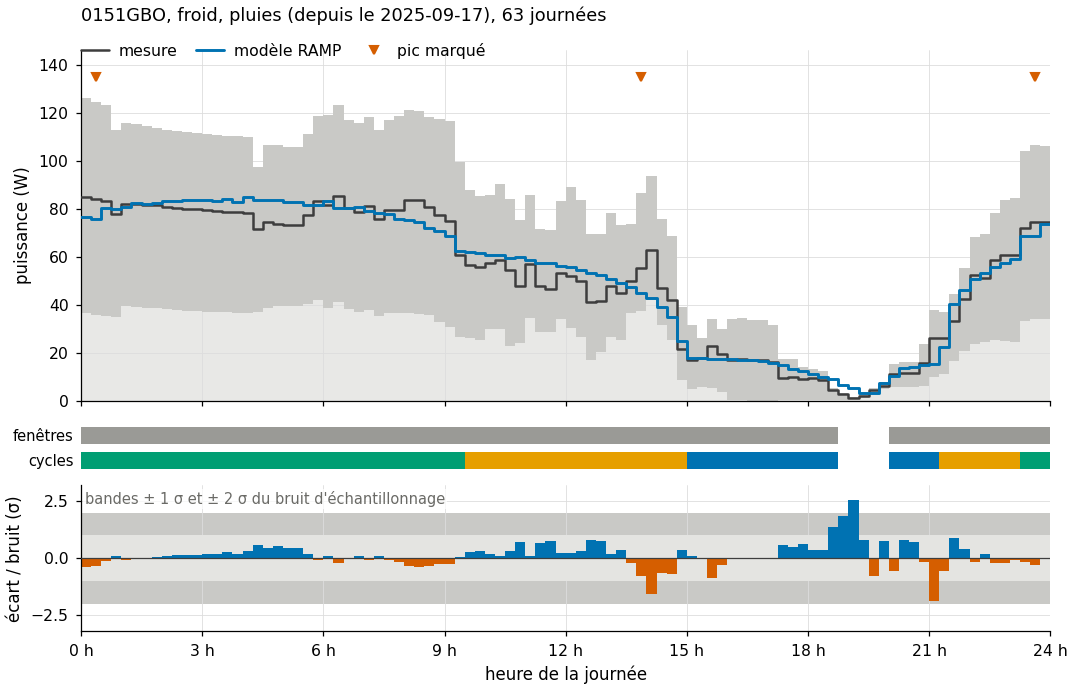

**Saison seche | avant 2025-09-17**

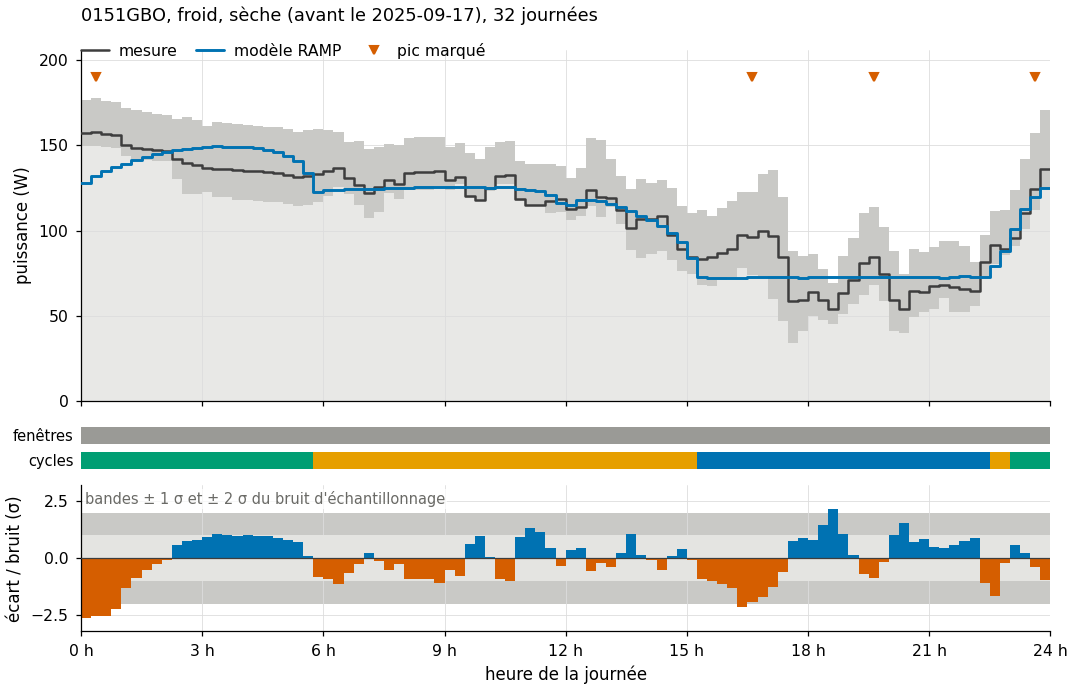

**Saison seche | depuis 2025-09-17**

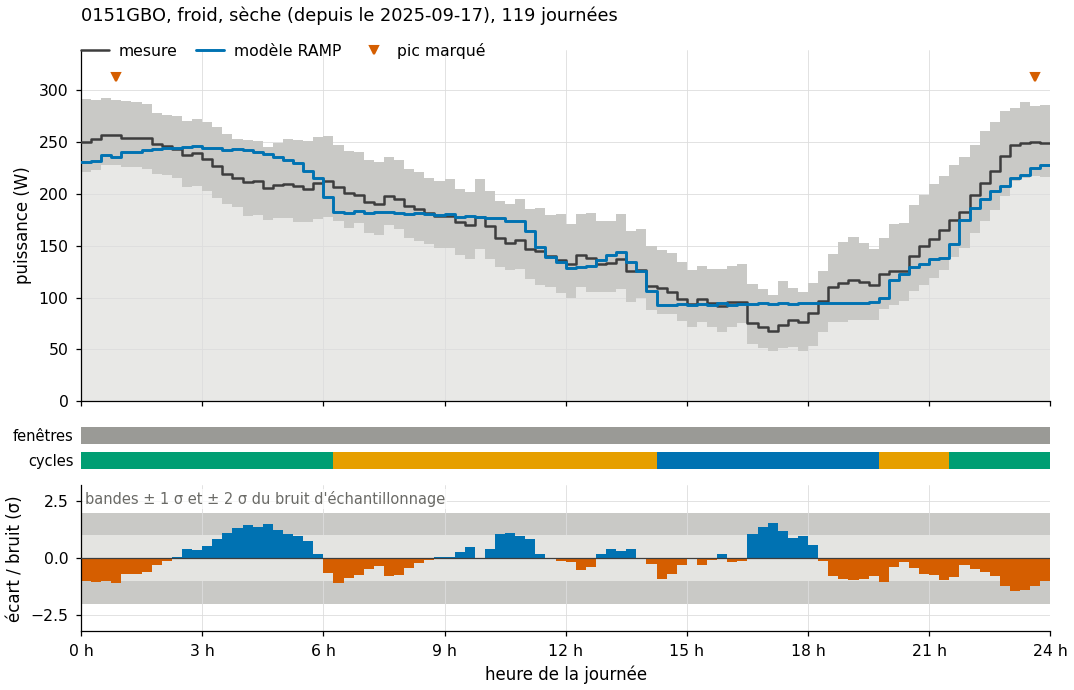

In [4]:
for p in seasons:
    display(Markdown(f"**{p['cible']}**"))
    show(SEASONS / "publication" / "figures" / "cibles", f"{p['nom']}.png")

### RAMP input files

Each file declares the appliance as a RAMP user would write it, with the nameplate power as
`power` and `p_i1`. It runs on its own: `python resultats/reference_saison/entrees_ramp/<target>.py`.

In [5]:
for p in seasons:
    display(Markdown(f"**{p['cible']}**"))
    print((SEASONS / "entrees_ramp" / f"{p['nom']}.py").read_text().split("if __name__")[0])

**Mai | avant 2025-09-17**

# 0151GBO, Mai | avant 2025-09-17 : froid, plaque 220 W. Parametres RAMP calibres le 19/09/2026 (plan d'audit, etape 3).


def declarer(user):
    app = user.add_appliance(name="cold_chain", number=1, power=220,
        num_windows=2, func_time=1365, func_cycle=10,
        fixed="yes", fixed_cycle=3, continuous_duty_cycle=1,
        occasional_use=1.000, flat="no", thermal_p_var=0,
        time_fraction_random_variability=0, pref_index=0, wd_we_type=2)
    app.windows(random_var_w=0.1, window_1=[0, 1200], window_2=[1275, 1440])
    app.specific_cycle(1, p_11=220, t_11=6, p_12=10.0, t_12=26, r_c1=0, cw11=[885, 1200], cw12=[1275, 1320])
    app.specific_cycle(2, p_21=220, t_21=11, p_22=10.0, t_22=9, r_c2=0, cw21=[150, 540], cw22=[1320, 1440])
    app.specific_cycle(3, p_31=220, t_31=11, p_32=10.0, t_32=2, r_c3=0, cw31=[0, 150], cw32=[540, 885])





**Mai | depuis 2025-09-17**

# 0151GBO, Mai | depuis 2025-09-17 : froid, plaque 220 W + 220 W. Parametres RAMP calibres le 19/09/2026 (plan d'audit, etape 3).


def declarer(user):
    app1 = user.add_appliance(name="cold_chain_1", number=1, power=220,
        num_windows=2, func_time=1155, func_cycle=15,
        fixed="yes", fixed_cycle=3, continuous_duty_cycle=1,
        occasional_use=1.000, flat="no", thermal_p_var=0,
        time_fraction_random_variability=0, pref_index=0, wd_we_type=2)
    app1.windows(random_var_w=0.1, window_1=[0, 960], window_2=[1230, 1440])
    app1.specific_cycle(1, p_11=220, t_11=2, p_12=5.0, t_12=14, r_c1=0, cw11=[0, 330], cw12=[1230, 1440])
    app1.specific_cycle(2, p_21=220, t_21=2, p_22=5.0, t_22=10, r_c2=0, cw21=[540, 705], cw22=[870, 960])
    app1.specific_cycle(3, p_31=220, t_31=11, p_32=5.0, t_32=12, r_c3=0, cw31=[330, 540], cw32=[705, 870])
    app2 = user.add_appliance(name="cold_chain_2", number=1, power=220,
        num_windows=2, func_time=1155, func_cycle=15,
        f

**Octobre | depuis 2025-09-17**

...

# 0151GBO, Saison des pluies | depuis 2025-09-17 : froid, plaque 220 W + 220 W. Parametres RAMP calibres le 19/09/2026 (plan d'audit, etape 3).


def declarer(user):
    app1 = user.add_appliance(name="cold_chain_1", number=1, power=220,
        num_windows=2, func_time=1350, func_cycle=15,
        fixed="yes", fixed_cycle=3, continuous_duty_cycle=1,
        occasional_use=0.746, flat="no", thermal_p_var=0,
        time_fraction_random_variability=0, pref_index=0, wd_we_type=2)
    app1.windows(random_var_w=0.1, window_1=[0, 1125], window_2=[1200, 1440])
    app1.specific_cycle(1, p_11=220, t_11=1, p_12=5.0, t_12=31, r_c1=0, cw11=[900, 1125], cw12=[1200, 1275])
    app1.specific_cycle(2, p_21=220, t_21=3, p_22=5.0, t_22=11, r_c2=0, cw21=[570, 900], cw22=[1275, 1395])
    app1.specific_cycle(3, p_31=220, t_31=12, p_32=5.0, t_32=27, r_c3=0, cw31=[0, 570], cw32=[1395, 1440])
    app2 = user.add_appliance(name="cold_chain_2", number=1, power=220,
        num_windows=2, func_time=1350, func

**Saison seche | avant 2025-09-17**

# 0151GBO, Saison seche | avant 2025-09-17 : froid, plaque 220 W. Parametres RAMP calibres le 19/09/2026 (plan d'audit, etape 3).


def declarer(user):
    app = user.add_appliance(name="cold_chain", number=1, power=220,
        num_windows=2, func_time=1440, func_cycle=5,
        fixed="yes", fixed_cycle=3, continuous_duty_cycle=1,
        occasional_use=1.000, flat="no", thermal_p_var=0,
        time_fraction_random_variability=0, pref_index=0, wd_we_type=2)
    app.windows(random_var_w=0.0, window_1=[0, 720], window_2=[720, 1440])
    app.specific_cycle(1, p_11=220, t_11=4, p_12=10.0, t_12=11, r_c1=0, cw11=[915, 1350])
    app.specific_cycle(2, p_21=220, t_21=9, p_22=10.0, t_22=6, r_c2=0, cw21=[345, 915], cw22=[1350, 1380])
    app.specific_cycle(3, p_31=220, t_31=13, p_32=10.0, t_32=1, r_c3=0, cw31=[0, 345], cw32=[1380, 1440])





**Saison seche | depuis 2025-09-17**

# 0151GBO, Saison seche | depuis 2025-09-17 : froid, plaque 220 W + 220 W. Parametres RAMP calibres le 19/09/2026 (plan d'audit, etape 3).


def declarer(user):
    app1 = user.add_appliance(name="cold_chain_1", number=1, power=220,
        num_windows=2, func_time=1440, func_cycle=15,
        fixed="yes", fixed_cycle=3, continuous_duty_cycle=1,
        occasional_use=1.000, flat="no", thermal_p_var=0,
        time_fraction_random_variability=0, pref_index=0, wd_we_type=2)
    app1.windows(random_var_w=0.1, window_1=[0, 720], window_2=[720, 1440])
    app1.specific_cycle(1, p_11=220, t_11=6, p_12=5.0, t_12=25, r_c1=0, cw11=[855, 1185])
    app1.specific_cycle(2, p_21=220, t_21=12, p_22=5.0, t_22=16, r_c2=0, cw21=[375, 855], cw22=[1185, 1290])
    app1.specific_cycle(3, p_31=220, t_31=12, p_32=5.0, t_32=4, r_c3=0, cw31=[0, 375], cw32=[1290, 1440])
    app2 = user.add_appliance(name="cold_chain_2", number=1, power=220,
        num_windows=2, func_time=1440, func_cycle=15,
        fixed="

### Replay

The RAMP engine is run again on each input file with the check seeds (20 runs of 480 days).
It must give back the published profile exactly. A few seconds per target.

In [6]:
for p in seasons:
    text = (SEASONS / "entrees_ramp" / f"{p['nom']}.py").read_text()
    profile = K.simulate(text, K.SEEDS_CHECK[0], 20)
    published = np.load(SEASONS / f"{p['nom']}_profil.npy")
    print(f"{p['cible']:<40} identical to the published profile: {np.array_equal(profile, published)}")

Mai | avant 2025-09-17                   identical to the published profile: True


Mai | depuis 2025-09-17                  identical to the published profile: True


Octobre | depuis 2025-09-17              identical to the published profile: True


Saison des pluies | avant 2025-09-17     identical to the published profile: True


Saison des pluies | depuis 2025-09-17    identical to the published profile: True


Saison seche | avant 2025-09-17          identical to the published profile: True


Saison seche | depuis 2025-09-17         identical to the published profile: True


## Months

One target per calendar month and fleet configuration. The duration `func_cycle` is inherited
from the seasonal target of the same client and season; everything else is searched month by
month.

In [7]:
summary(months)

,target,days,verdict,missed criteria,NRMSE (%),harmonics (%),energy (%),peak time (h),func_cycle (min),period (min)
0,Avril | avant 2025-09-17,23,non verifiable,"FFT_err, CORR_h, EXT_prof, ECART_PICS_h, ELM_1h",13.9,24.3,2.1,3.00,5,15
1,Avril | depuis 2025-09-17,20,non verifiable,"FFT_err, ECART_PICS_h",9.5,31.1,0.2,3.00,15,30
2,Decembre | depuis 2025-09-17,11,non verifiable,"FFT_err, ECART_PICS_h",16.5,23.6,0.8,3.00,15,30
3,Fevrier | depuis 2025-09-17,19,rejetee,"FFT_err, ECART_PICS_h, ELM_1h, ELM_2h",10.6,25.5,0.5,3.00,15,15
4,Janvier | depuis 2025-09-17,16,rejetee,"FFT_err, ECART_PICS_h, ELM_1h",7.1,24.2,-0.4,3.00,15,30
5,Juillet | avant 2025-09-17,21,non verifiable,-,5.6,13.8,-0.8,1.00,15,30
6,Juillet | depuis 2025-09-17,23,non verifiable,"FFT_err, ECART_PICS_h",7.3,34.2,2.0,3.00,15,30
7,Juin | avant 2025-09-17,26,non verifiable,FFT_err,7.0,22.5,-1.5,0.00,15,30
8,Juin | depuis 2025-09-17,29,non verifiable,ELM_1h,6.2,11.3,-0.5,0.25,15,15
9,Mai | avant 2025-09-17,28,rejetee,FFT_err,8.3,25.1,-0.0,0.75,10,30


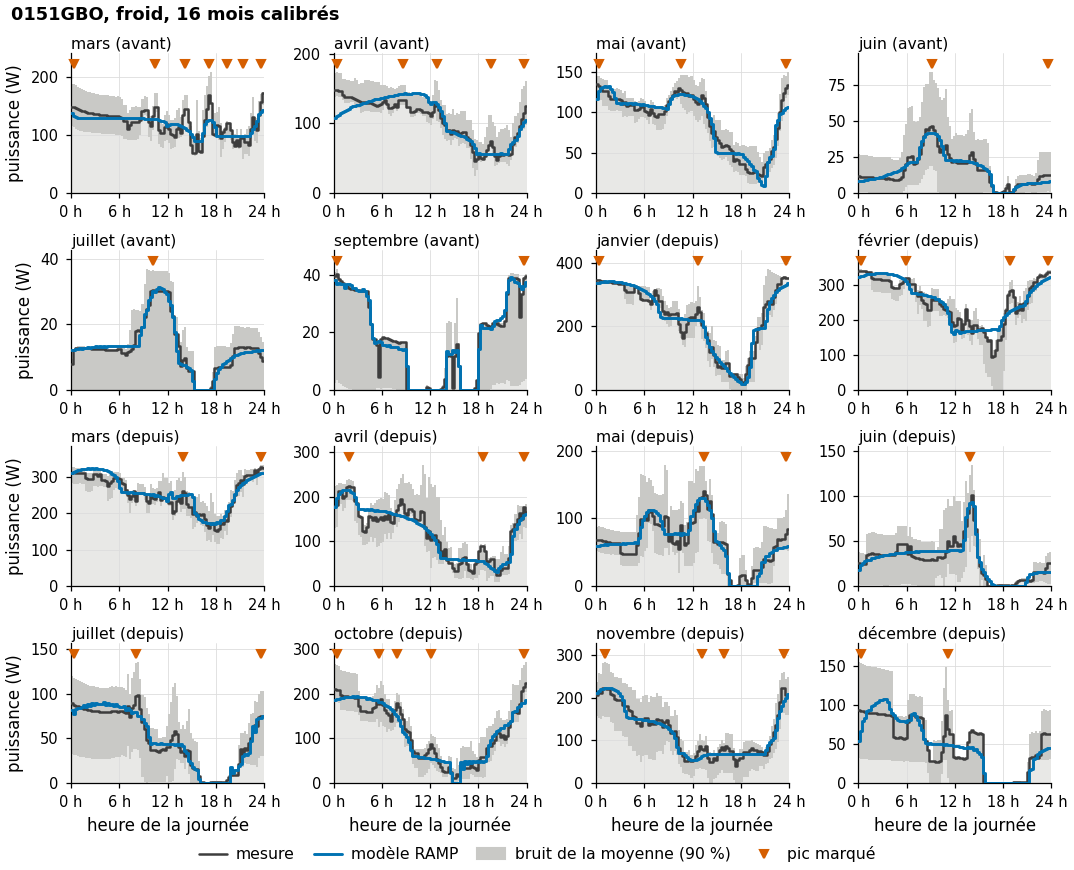

In [8]:
show(MONTHS / "publication" / "figures", f"multiples_client_{CLIENT}.png")

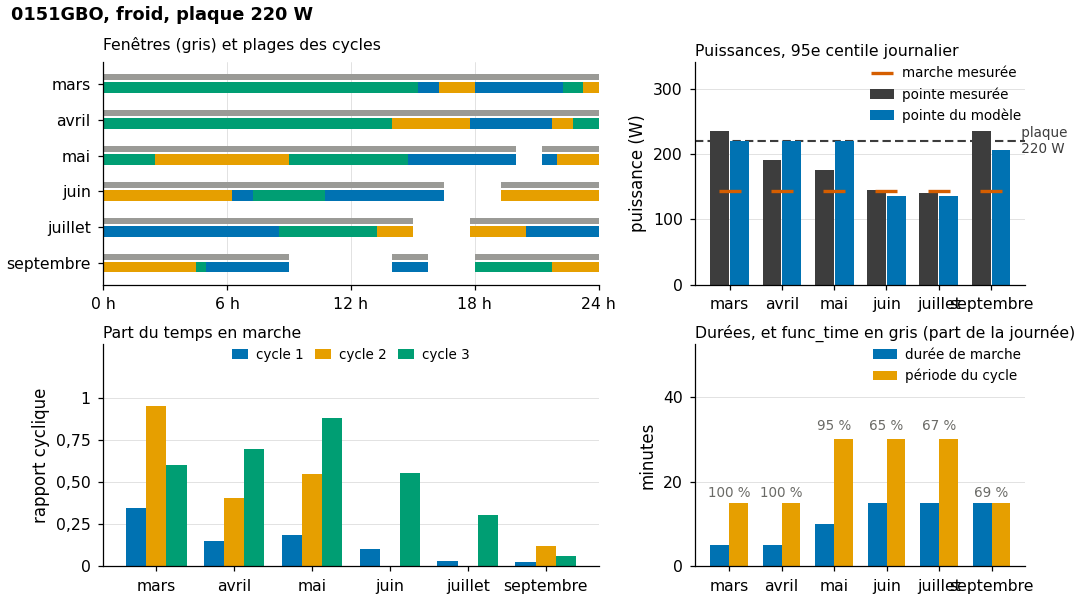

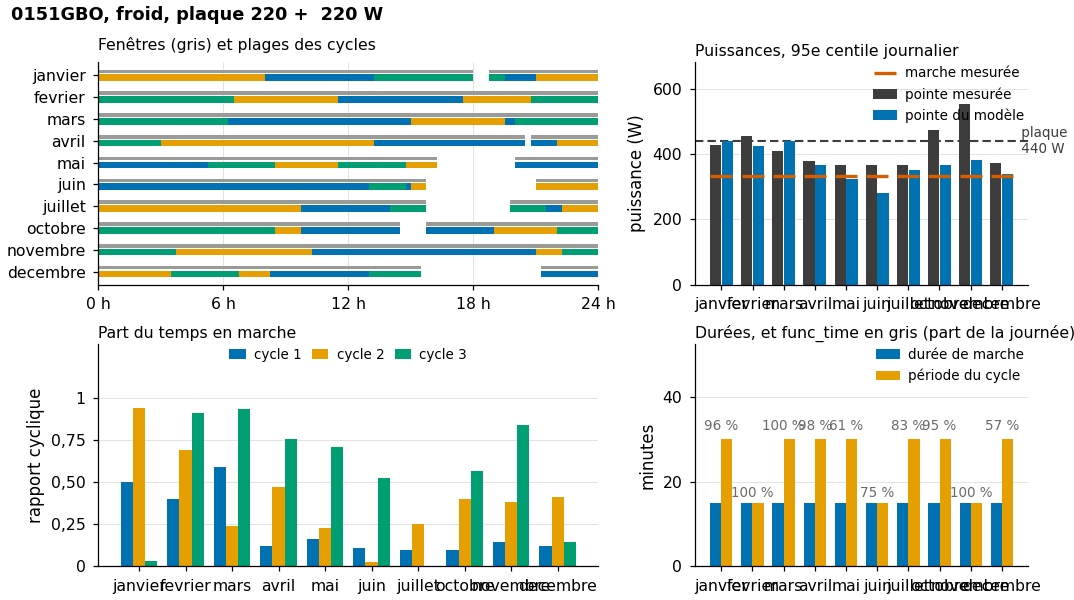

In [9]:
show(MONTHS / "publication" / "figures", f"parametres_{CLIENT}_*.png")